![interpreto_banner](../../assets/img/interpreto_banner.png){ style="display:block; max-width:100%; height:auto; margin:0 auto;" }

# Probing a Sentiment Classifier for Linguistic Properties

In this tutorial we demonstrate **supervised probing** with `interpreto.concepts.probes`.

The idea is simple: a model trained for *sentiment analysis* might also encode **other linguistic properties** in its hidden representations — such as sentence length, presence of negation, or dominant tense. Probes let us test this hypothesis by training lightweight classifiers on the model's internal activations.

This approach is inspired by the probing literature (Conneau et al. 2018, "What you can cram into a single \$&!#* vector").

**Steps:**

1. [🏗️ **Setup**: Load the model and split it](#setup)
2. [📊 **Data**: Load IMDB and compute linguistic labels](#data)
3. [🚦 **Activations**: Extract CLS-token representations](#activations)
4. [🏋️ **Fit probes**: Train several probe types](#fit)
5. [📈 **Evaluate**: Compare probe performance](#evaluate)
6. [💬 **Discussion**](#discussion)

*Author: Antonin Poché*

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. 🏗️ Setup: Load the model and split it <a class="anchor" id="setup"></a>

We use a DistilBERT model fine-tuned for binary sentiment classification on IMDB.

We wrap it with [`SplitSequenceClassification`](https://for-sight-ai.github.io/interpreto/api/concepts/split_sequence_classification/), which splits the model at the classification head and extracts [CLS] token activations.

> ➡️ **Note**
>
> The model was trained to predict *sentiment*. We will probe whether its internal representations also encode *other* linguistic properties — properties that were never part of its training objective.

In [2]:
from interpreto import SplitterForClassification

splitter = SplitterForClassification(
    model_or_repo_id="textattack/distilbert-base-uncased-imdb",
    device_map=DEVICE,
    batch_size=64,
)

## 2. 📊 Data: Load IMDB and compute linguistic labels <a class="anchor" id="data"></a>

We load a subset of the IMDB test set (1000 samples) — the same domain the model was trained on.

We then compute **three binary linguistic labels** from the text itself:

| Concept | Definition |
|---------|------------|
| **Length** | Is the review longer than the median length? |
| **Negation** | Does the text contain negation words (not, never, no, don't, ...)? |
| **Past tense** | Is the text predominantly in the past tense? |

> 🔥 **Tip**
>
> These labels are computed from the raw text, not from the model's predictions. The point of probing is to test what *other* information the model's representations encode beyond its training objective.

In [3]:
import re

from datasets import load_dataset

# Load IMDB test set (1000 samples for tractability)
dataset = load_dataset("stanfordnlp/imdb", split="test[:1000]")
texts = dataset["text"]

print(f"Loaded {len(texts)} samples")
print(f"Example (first 200 chars): {texts[0][:200]}...")

Loaded 1000 samples
Example (first 200 chars): I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab...


In [4]:
import numpy as np

# --- Concept 1: Sentence length (long vs short) ---
lengths = [len(text.split()) for text in texts]
median_length = np.median(lengths)
is_long = [1.0 if l >= median_length else 0.0 for l in lengths]

# --- Concept 2: Contains negation ---
NEGATION_WORDS = {
    "not",
    "no",
    "never",
    "neither",
    "nobody",
    "nothing",
    "nowhere",
    "nor",
    "don't",
    "doesn't",
    "didn't",
    "won't",
    "wouldn't",
    "shouldn't",
    "couldn't",
    "isn't",
    "aren't",
    "wasn't",
    "weren't",
    "hasn't",
    "haven't",
    "hadn't",
}


def has_negation(text: str) -> float:
    words = set(re.findall(r"\b\w[\w']*\b", text.lower()))
    return 1.0 if words & NEGATION_WORDS else 0.0


contains_negation = [has_negation(text) for text in texts]

# --- Concept 3: Past tense dominant ---
PAST_MARKERS = {"was", "were", "had", "did", "been", "went", "said", "told", "made", "got"}
PRESENT_MARKERS = {"is", "are", "has", "does", "do", "goes", "says", "tells", "makes", "gets"}


def is_past_tense(text: str) -> float:
    words = re.findall(r"\b\w+\b", text.lower())
    past_count = sum(1 for w in words if w in PAST_MARKERS)
    present_count = sum(1 for w in words if w in PRESENT_MARKERS)
    return 1.0 if past_count > present_count else 0.0


past_tense = [is_past_tense(text) for text in texts]

# --- Combine into a multi-label tensor (n, 3) ---
labels = torch.tensor(
    list(zip(is_long, contains_negation, past_tense, strict=True)),
    dtype=torch.float32,
)
CONCEPT_NAMES = ["long_text", "contains_negation", "past_tense"]

print(f"Labels shape: {labels.shape}")
print(f"Label prevalence: {labels.mean(dim=0).tolist()}")
print(f"  - Long text:         {labels[:, 0].mean():.2%}")
print(f"  - Contains negation: {labels[:, 1].mean():.2%}")
print(f"  - Past tense:        {labels[:, 2].mean():.2%}")

Labels shape: torch.Size([1000, 3])
Label prevalence: [0.5019999742507935, 0.9210000038146973, 0.2879999876022339]
  - Long text:         50.20%
  - Contains negation: 92.10%
  - Past tense:        28.80%


## 3. 🚦 Activations: Extract CLS-token representations <a class="anchor" id="activations"></a>

We extract the [CLS] token activation for each sample. This is the vector that feeds the classification head — a single 768-dimensional vector summarizing the entire input.

[`SplitSequenceClassification.get_activations()`](https://for-sight-ai.github.io/interpreto/api/concepts/split_sequence_classification/#interpreto.SplitSequenceClassification.get_activations)

In [5]:
# Extract CLS activations — shape (n, d)
activations, _ = splitter.get_activations(texts, tqdm_bar=True, forward_kwargs={"truncation": True})

print(f"Activations shape: {activations.shape}")
# Expected: (1000, 768) for DistilBERT

  0%|          | 0/16 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:03<00:00,  4.85it/s]


Activations shape: torch.Size([1000, 768])


## 4. 🏋️ Fit probes: Train several probe types <a class="anchor" id="fit"></a>

We split the data into train/test, then train three different probes:

| Probe | Description |
|-------|-------------|
| [`LinearRegressionProbe`](https://for-sight-ai.github.io/interpreto/api/concepts/probes/) | Ridge regression (closed-form) |
| [`CosineCentroidProbe`](https://for-sight-ai.github.io/interpreto/api/concepts/probes/) | Cosine similarity to class centroids |
| [`LogisticRegressionProbe`](https://for-sight-ai.github.io/interpreto/api/concepts/probes/) | Gradient-descent logistic regression |

All probes learn a mapping from activations to concept scores: `(n, d) → (n, c)` where `c=3` (our three linguistic concepts).

> ➡️ **Note**
>
> We wrap each probe in a [`ProbeExplainer`](https://for-sight-ai.github.io/interpreto/api/concepts/probes/) which connects it to the split model. The explainer handles activation format validation and device management.

In [6]:
from sklearn.model_selection import train_test_split

# Train/test split (80/20)
indices = list(range(len(texts)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_activations = activations[train_idx]
test_activations = activations[test_idx]
train_labels = labels[train_idx]
test_labels = labels[test_idx]

print(f"Train: {train_activations.shape[0]} samples")
print(f"Test:  {test_activations.shape[0]} samples")

Train: 800 samples
Test:  200 samples


In [7]:
from interpreto.concepts.probes import (
    CosineCentroidProbe,
    LinearRegressionProbe,
    LogisticRegressionProbe,
    ProbeExplainer,
    Standardization,
)

# Define probe configurations
probe_configs = {
    "LinearRegression (ridge)": LinearRegressionProbe(l2=1e-3),
    "CosineCentroid": CosineCentroidProbe(normalization=Standardization()),
    "LogisticRegression": LogisticRegressionProbe(lr=1e-2, max_iter=200),
}

# Train each probe
explainers = {}
for name, probe in probe_configs.items():
    explainer = ProbeExplainer(splitter, probe)
    explainer.fit(train_activations, train_labels)
    explainers[name] = explainer
    print(f"✓ {name} fitted (is_fitted={explainer.is_fitted})")

✓ LinearRegression (ridge) fitted (is_fitted=True)
✓ CosineCentroid fitted (is_fitted=True)


✓ LogisticRegression fitted (is_fitted=True)


## 5. 📈 Evaluate: Compare probe performance <a class="anchor" id="evaluate"></a>

We evaluate each probe on the held-out test set using **AUROC** (Area Under the ROC Curve), which measures how well the probe's scores separate positive from negative samples for each concept.

An AUROC significantly above 0.5 (chance level) means the model's representations **do encode** that linguistic property.

In [8]:
from sklearn.metrics import roc_auc_score

results = {}

for name, explainer in explainers.items():
    # Get concept scores on test set
    scores = explainer.activations_to_concepts(test_activations)  # (n_test, 3)

    # Compute AUROC per concept
    aurocs = []
    for c in range(labels.shape[1]):
        y_true = test_labels[:, c].numpy()
        y_score = scores[:, c].detach().cpu().numpy()
        # Only compute if both classes are present
        if len(set(y_true)) > 1:
            aurocs.append(roc_auc_score(y_true, y_score))
        else:
            aurocs.append(float("nan"))

    results[name] = aurocs

# Display results table
print(f"{'Probe':<30} {'Long text':<12} {'Negation':<12} {'Past tense':<12} {'Mean':<8}")
print("-" * 74)
for name, aurocs in results.items():
    mean_auroc = np.nanmean(aurocs)
    print(f"{name:<30} {aurocs[0]:<12.3f} {aurocs[1]:<12.3f} {aurocs[2]:<12.3f} {mean_auroc:<8.3f}")

Probe                          Long text    Negation     Past tense   Mean    
--------------------------------------------------------------------------
LinearRegression (ridge)       0.574        0.571        0.631        0.592   
CosineCentroid                 0.609        0.677        0.646        0.644   
LogisticRegression             0.824        0.727        0.719        0.757   


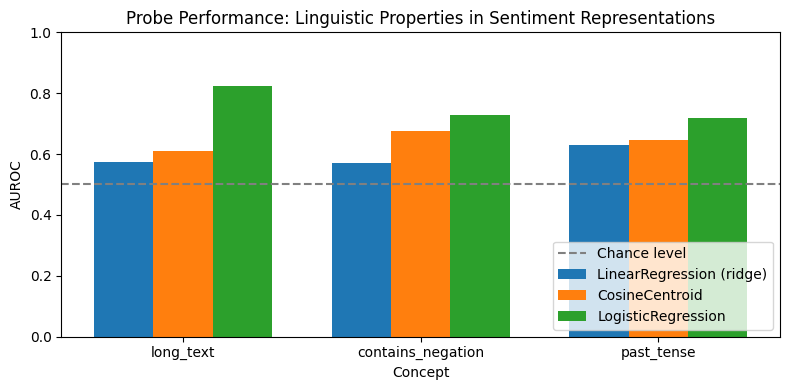

In [9]:
import matplotlib.pyplot as plt

# Visualize results
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(CONCEPT_NAMES))
width = 0.25

for i, (name, aurocs) in enumerate(results.items()):
    ax.bar(x + i * width, aurocs, width, label=name)

ax.axhline(y=0.5, color="gray", linestyle="--", label="Chance level")
ax.set_xlabel("Concept")
ax.set_ylabel("AUROC")
ax.set_title("Probe Performance: Linguistic Properties in Sentiment Representations")
ax.set_xticks(x + width)
ax.set_xticklabels(CONCEPT_NAMES)
ax.legend(loc="lower right")
ax.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 6. 💬 Discussion <a class="anchor" id="discussion"></a>

### What do the results tell us?

- **High AUROC for negation**: The sentiment model strongly encodes negation — this makes sense, as negation flips sentiment polarity ("good" vs "not good").
- **Moderate AUROC for length**: Sentence length is partially encoded, possibly because longer reviews tend to be more nuanced.
- **Variable AUROC for tense**: Past tense encoding depends on the model and dataset — movie reviews are typically in past tense ("the movie was..."), so this may be less discriminative.

### Probing caveats

A high probe accuracy does not prove the model *uses* that information for its task — only that the information is *recoverable* from the representations. See Hewitt & Liang (2019) for a discussion of probe expressivity and selectivity.

### Next steps

- Try probing at **different layers** to see where each property is encoded (earlier layers for syntax, later for semantics).
- Use [`MeansDiffProbe`](https://for-sight-ai.github.io/interpreto/api/concepts/probes/) as a minimal baseline (Fisher's discriminant direction).
- Combine probes with **concept attribution** to see which input activates the concept.

### References

- Conneau et al. (2018). *What you can cram into a single \$&!#\* vector: Probing sentence embeddings for linguistic properties.* ACL.
- Hewitt & Liang (2019). *Designing and interpreting probes with control tasks.* EMNLP.